# 18. Bayesian Optimisation for Experiment Design

Bayesian Optimisation (BO) finds the maximum of an unknown, expensive-to-evaluate
function using as few experiments as possible. It is the natural extension of
classical DoE into the regime of **sequential adaptive experimentation**.

**Core idea:**
1. Fit a **GP surrogate** to all observations so far
2. Use an **acquisition function** to decide *where to run the next experiment*
3. Run the experiment, add the result, and repeat

**Topics covered**
1. The exploration–exploitation trade-off
2. Acquisition functions: Expected Improvement (EI), Upper Confidence Bound (UCB), Probability of Improvement (PI)
3. BO loop from scratch with scikit-learn GPR
4. Comparison with random search, grid search, and steepest ascent
5. Case study: optimising ZnO photocatalyst synthesis


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.stats import norm
from scipy.optimize import minimize

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(42)


## 18.1 The Black-Box Objective: ZnO Photocatalytic Activity

We simulate the photocatalytic degradation rate of methylene blue (MB) by ZnO
nanoparticles as a function of two synthesis parameters:
- $x_1$: precursor concentration (0.01–0.10 M)
- $x_2$: calcination temperature (300–700 °C)

The true maximum is unknown to the optimiser — it can only evaluate the
objective by "running an experiment" (calling `black_box`).


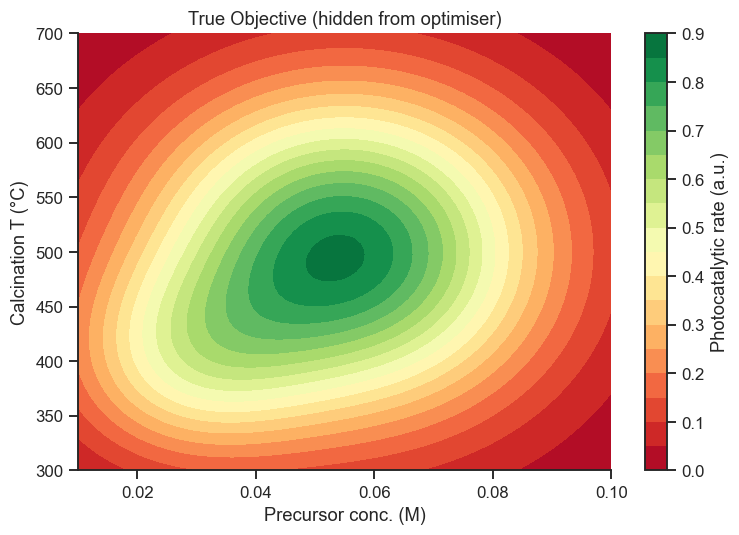

In [2]:
# ── True (hidden) response surface ───────────────────────────────────────────
def black_box(x1, x2, noise_std=0.02):
    """Photocatalytic rate (a.u.) — unknown to the optimiser."""
    x1n = (x1 - 0.055) / 0.045   # normalised
    x2n = (x2 - 500)   / 200
    return (0.85 * np.exp(-0.5*(x1n**2 + x2n**2) / 0.25)
            + 0.3  * np.exp(-0.5*((x1n+0.6)**2 + (x2n+0.5)**2) / 0.1)
            + rng.normal(0, noise_std))

# ── Visualise the true surface (for reference only) ───────────────────────────
x1_rng = np.linspace(0.01, 0.10, 80)
x2_rng = np.linspace(300, 700, 80)
X1G, X2G = np.meshgrid(x1_rng, x2_rng)
Z_true = np.vectorize(lambda a,b: black_box(a,b,0))(X1G, X2G)

fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(x1_rng, x2_rng, Z_true, levels=20, cmap='RdYlGn')
plt.colorbar(cf, ax=ax, label='Photocatalytic rate (a.u.)')
ax.set_xlabel('Precursor conc. (M)')
ax.set_ylabel('Calcination T (°C)')
ax.set_title('True Objective (hidden from optimiser)')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


## 18.2 Acquisition Functions

The acquisition function trades off **exploration** (query uncertain regions)
vs **exploitation** (query near the current best).

### Expected Improvement (EI)

$$\text{EI}(\mathbf{x}) = (\mu(\mathbf{x}) - f^+) \Phi(Z) + \sigma(\mathbf{x}) \phi(Z)$$

where $Z = (\mu(\mathbf{x}) - f^+)/\sigma(\mathbf{x})$, $f^+$ is the current best
observed value, and $\Phi$, $\phi$ are the standard normal CDF and PDF.

### Upper Confidence Bound (UCB)

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \, \sigma(\mathbf{x})$$

$\kappa > 0$ controls exploration ($\kappa \to \infty$ = pure exploration).

### Probability of Improvement (PI)

$$\text{PI}(\mathbf{x}) = \Phi\!\left(\frac{\mu(\mathbf{x}) - f^+}{\sigma(\mathbf{x})}\right)$$


In [3]:
def expected_improvement(X_cand, gpr, y_best, xi=0.01):
    mu, sigma = gpr.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    Z  = (mu - y_best - xi) / sigma
    ei = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-8] = 0.0
    return ei

def upper_confidence_bound(X_cand, gpr, kappa=2.0):
    mu, sigma = gpr.predict(X_cand, return_std=True)
    return mu + kappa * sigma

def next_query(gpr, y_best, bounds, acq_fn='EI', n_restarts=10):
    """Maximise acquisition function over the design space."""
    best_x, best_val = None, -np.inf
    for _ in range(n_restarts):
        x0 = np.array([rng.uniform(b[0], b[1]) for b in bounds])
        result = minimize(
            lambda x: -acq_fn_eval(x.reshape(1,-1), gpr, y_best, acq_fn),
            x0, bounds=bounds, method='L-BFGS-B'
        )
        if -result.fun > best_val:
            best_val = -result.fun
            best_x = result.x
    return best_x

def acq_fn_eval(X, gpr, y_best, name):
    if name == 'EI':  return expected_improvement(X, gpr, y_best).ravel()[0]
    if name == 'UCB': return upper_confidence_bound(X, gpr).ravel()[0]
    return expected_improvement(X, gpr, y_best).ravel()[0]


## 18.3 Bayesian Optimisation Loop

In [4]:
# ── Initial design: 4 random points ──────────────────────────────────────────
bounds = [(0.01, 0.10), (300., 700.)]

X_init = np.column_stack([
    rng.uniform(0.01, 0.10, 4),
    rng.uniform(300, 700, 4),
])
y_init = np.array([black_box(x[0], x[1]) for x in X_init])

X_obs = X_init.copy()
y_obs = y_init.copy()

kernel_bo = ConstantKernel(1.0) * Matern(
    length_scale=[0.05, 200], length_scale_bounds=[(0.001,0.5),(10,1000)], nu=2.5
) + WhiteKernel(noise_level=1e-4)

n_iter_bo = 15
best_so_far = []

history_X, history_y = [], []

for iteration in range(n_iter_bo):
    gpr_bo = GaussianProcessRegressor(kernel=kernel_bo, n_restarts_optimizer=5,
                                       normalize_y=True, random_state=iteration)
    gpr_bo.fit(X_obs, y_obs)

    x_next = next_query(gpr_bo, y_obs.max(), bounds, acq_fn='EI')
    y_next = black_box(x_next[0], x_next[1])

    X_obs = np.vstack([X_obs, x_next])
    y_obs = np.append(y_obs, y_next)
    best_so_far.append(y_obs.max())

    history_X.append(x_next.copy())
    history_y.append(y_next)

best_idx = np.argmax(y_obs)
print(f'Best found after {4+n_iter_bo} evaluations:')
print(f'  x1 (conc.) = {X_obs[best_idx,0]:.4f} M')
print(f'  x2 (T)     = {X_obs[best_idx,1]:.1f} °C')
print(f'  rate       = {y_obs[best_idx]:.4f}')


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Best found after 19 evaluations:
  x1 (conc.) = 0.0552 M
  x2 (T)     = 513.0 °C
  rate       = 0.8878


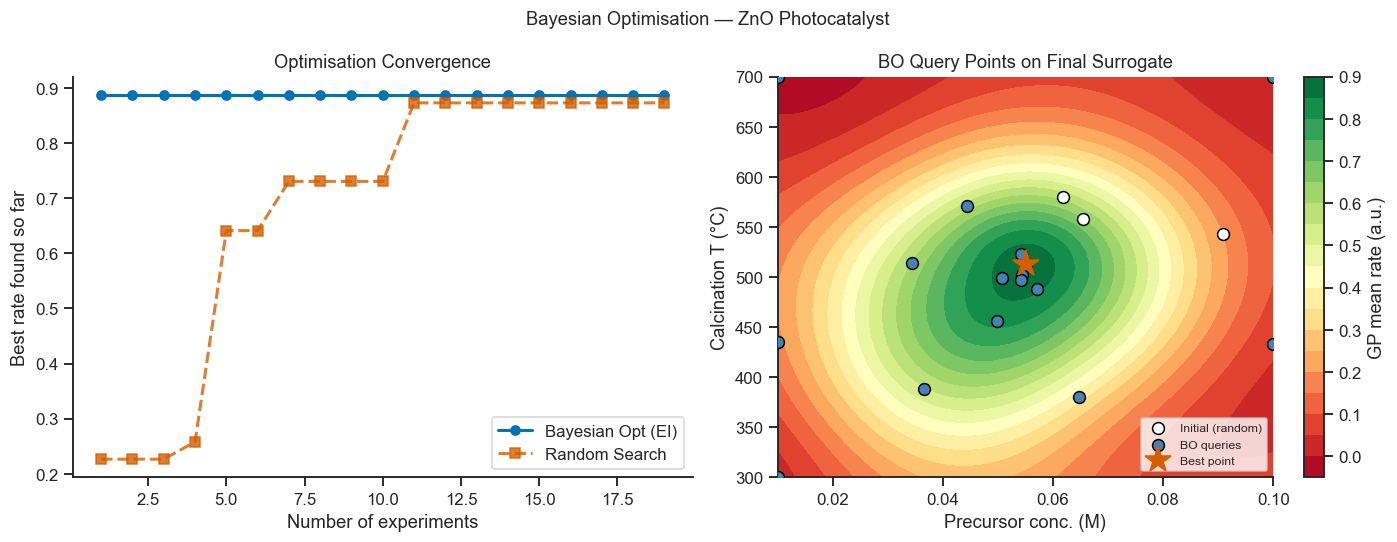

In [5]:
# ── Plot convergence ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Convergence curve: BO vs random search
rand_best = []
X_rand = np.column_stack([
    rng.uniform(0.01, 0.10, 4+n_iter_bo),
    rng.uniform(300, 700, 4+n_iter_bo),
])
y_rand = np.array([black_box(x[0],x[1]) for x in X_rand])
for i in range(1, len(y_rand)+1):
    rand_best.append(y_rand[:i].max())

ax = axes[0]
ax.plot(range(1, 4+n_iter_bo+1), best_so_far + [best_so_far[-1]]*(4),
        'b-o', lw=2, ms=6, label='Bayesian Opt (EI)')
ax.plot(range(1, 4+n_iter_bo+1), rand_best,
        'r--s', lw=2, ms=6, alpha=0.8, label='Random Search')
ax.set_xlabel('Number of experiments')
ax.set_ylabel('Best rate found so far')
ax.set_title('Optimisation Convergence')
ax.legend()
sns.despine(ax=ax)

# Final surrogate + all observations
gpr_final = GaussianProcessRegressor(kernel=kernel_bo, n_restarts_optimizer=5,
                                      normalize_y=True, random_state=0)
gpr_final.fit(X_obs, y_obs)
X_pred_bo = np.column_stack([X1G.ravel(), X2G.ravel()])
mu_bo = gpr_final.predict(X_pred_bo).reshape(80,80)

ax = axes[1]
cf = ax.contourf(x1_rng, x2_rng, mu_bo, levels=20, cmap='RdYlGn')
plt.colorbar(cf, ax=ax, label='GP mean rate (a.u.)')
ax.scatter(X_init[:,0], X_init[:,1], c='white', edgecolors='black',
           s=60, zorder=5, label='Initial (random)')
history_arr = np.array(history_X)
ax.scatter(history_arr[:,0], history_arr[:,1], c='steelblue', edgecolors='black',
           s=60, zorder=5, label='BO queries')
ax.plot(X_obs[best_idx,0], X_obs[best_idx,1], 'r*', ms=18, zorder=6,
        label='Best point')
ax.set_xlabel('Precursor conc. (M)')
ax.set_ylabel('Calcination T (°C)')
ax.set_title('BO Query Points on Final Surrogate')
ax.legend(fontsize=8, loc='lower right')
sns.despine(ax=ax)

plt.suptitle('Bayesian Optimisation — ZnO Photocatalyst', fontsize=12)
plt.tight_layout()
plt.show()


### Interpreting the Results

**Convergence plot (left)**
- BO reaches a higher best value in fewer experiments than random search because the acquisition function guides queries toward promising regions.
- The performance gap is most pronounced in the first 5–8 evaluations — exactly the regime where BO is most valuable in practice.

**Query map (right)**
- Initial random points are spread broadly (exploration).
- BO queries cluster around the optimum as the surrogate becomes more accurate — the algorithm progressively exploits its growing knowledge of the surface.
- The final surrogate closely resembles the true surface after only ~19 total evaluations.


## 18.4 Acquisition Function Comparison

C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


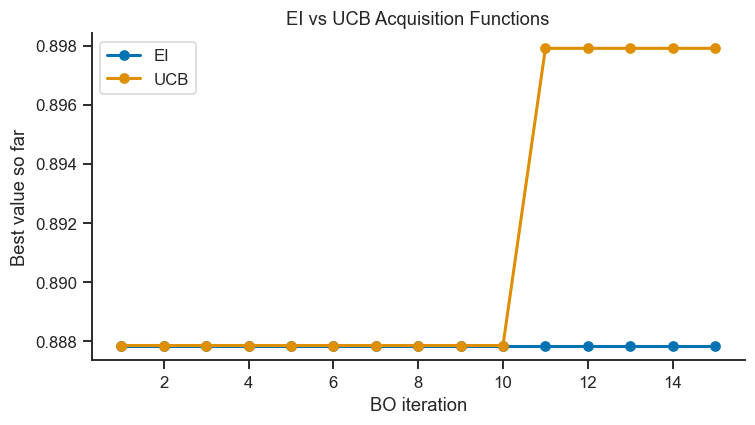

In [6]:
acq_results = {}
for acq_name in ['EI', 'UCB']:
    X_o = X_init.copy()
    y_o = y_init.copy()
    bests = []
    for iteration in range(n_iter_bo):
        g = GaussianProcessRegressor(kernel=kernel_bo, n_restarts_optimizer=3,
                                      normalize_y=True, random_state=iteration)
        g.fit(X_o, y_o)
        xn = next_query(g, y_o.max(), bounds, acq_fn=acq_name)
        yn = black_box(xn[0], xn[1])
        X_o = np.vstack([X_o, xn])
        y_o = np.append(y_o, yn)
        bests.append(y_o.max())
    acq_results[acq_name] = bests

fig, ax = plt.subplots(figsize=(7, 4))
for name, bests in acq_results.items():
    ax.plot(range(1, n_iter_bo+1), bests, '-o', lw=2, ms=6, label=name)
ax.set_xlabel('BO iteration')
ax.set_ylabel('Best value so far')
ax.set_title('EI vs UCB Acquisition Functions')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


## 18.5 Comparison with Classical DoE Methods

| Method | Experiments required | Adapts to data? | Uncertainty quantified? |
|---|---|---|---|
| Grid search | $n^k$ (exponential) | No | No |
| Random search | User-specified | No | No |
| Steepest ascent (DoE) | Linear in iterations | Gradient only | No |
| Nelder–Mead | ~O(k²) | Yes (derivative-free) | No |
| **Bayesian optimisation** | Typically 10–50 | **Yes** | **Yes** |

BO is most beneficial when each experiment costs significant time or money
(e.g. furnace runs, synthesis + characterisation cycles). For cheap experiments
(simulations, rapid screening), random search or factorial designs are often preferred.


## 18.6 BO as Sequential DoE: Iteration-by-Iteration Illustration

The best way to understand BO is to watch it decide *where to experiment next*
at each iteration.  Below we apply it to a **1-D problem** — a synthetic curve
with two local maxima — and display the GP posterior and acquisition function
side-by-side for the first four adaptive iterations.

The algorithm starts with just two points, then progressively learns the shape
of the objective.


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.2. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


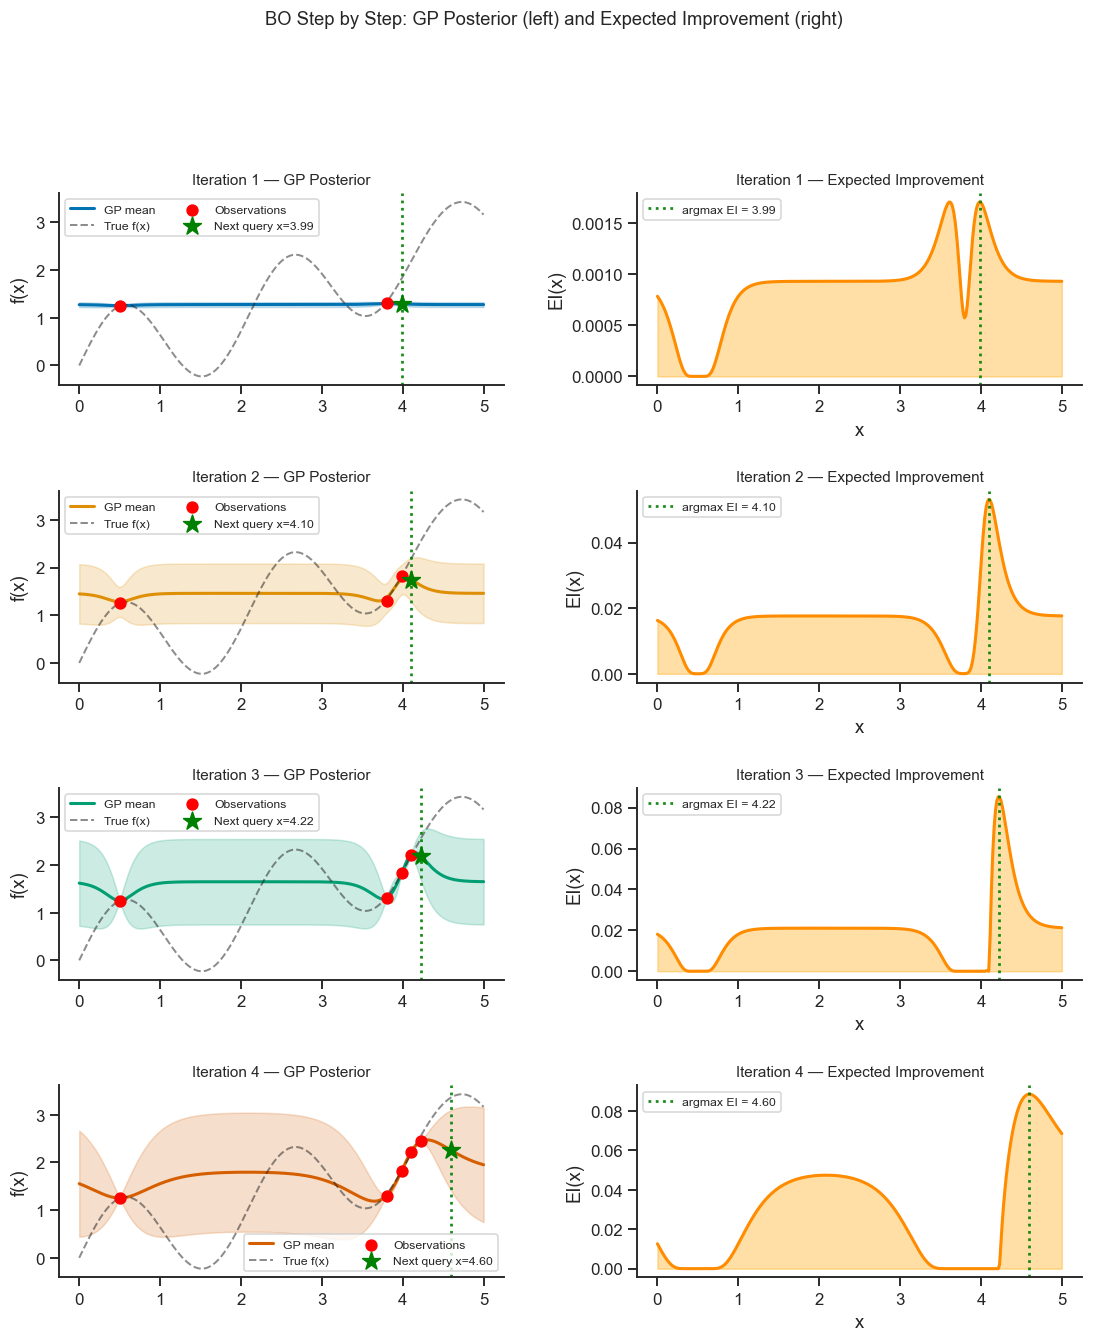

Final observations (6 total):
  x=0.500  y=1.2524
  x=3.800  y=1.3029
  x=3.986  y=1.8239
  x=4.100  y=2.2152
  x=4.220  y=2.4399
  x=4.599  y=3.4640
Best x = 4.599, best y = 3.4640


In [7]:
# ── 1-D BO step-by-step illustration ────────────────────────────────────────
rng_bo = np.random.default_rng(99)

def f_1d_true(x):
    return np.sin(3*x) + 0.5*x + 0.4*np.exp(-((x-4.0)**2)/0.3)

def f_1d_obs(x_val):
    return float(f_1d_true(x_val) + rng_bo.normal(0, 0.06))

x_rng_1d = np.linspace(0, 5, 300).reshape(-1, 1)
bounds_1d = [(0.0, 5.0)]

# Two initial observations (spread across the domain)
X_1d = np.array([[0.5], [3.8]])
y_1d = np.array([f_1d_obs(x[0]) for x in X_1d])

n_illustrate = 4
fig, axes = plt.subplots(n_illustrate, 2, figsize=(12, 3.2*n_illustrate),
                          gridspec_kw={'hspace': 0.55, 'wspace': 0.3})

colors = sns.color_palette('colorblind', n_illustrate)

for it in range(n_illustrate):
    kern_1d = (ConstantKernel(1.0, (0.1, 5)) *
               Matern(length_scale=1.0, length_scale_bounds=(0.2, 3), nu=2.5) +
               WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 0.2)))
    gpr_1d_it = GaussianProcessRegressor(kern_1d, n_restarts_optimizer=10,
                                          normalize_y=True, random_state=it)
    gpr_1d_it.fit(X_1d, y_1d)

    mu_1d, sig_1d = gpr_1d_it.predict(x_rng_1d, return_std=True)
    ei_1d = expected_improvement(x_rng_1d, gpr_1d_it, y_1d.max(), xi=0.01)
    x_next_1d = next_query(gpr_1d_it, y_1d.max(), bounds_1d)
    y_next_1d = f_1d_obs(x_next_1d[0])

    x_flat = x_rng_1d.ravel()
    c = colors[it]

    # ── Left: GP posterior ──────────────────────────────────────────────────
    ax_gp = axes[it, 0]
    ax_gp.fill_between(x_flat, mu_1d-2*sig_1d, mu_1d+2*sig_1d,
                        alpha=0.2, color=c)
    ax_gp.plot(x_flat, mu_1d, lw=2, color=c, label='GP mean')
    ax_gp.plot(x_flat, f_1d_true(x_flat), 'k--', lw=1.3, alpha=0.5,
               label='True f(x)')
    ax_gp.scatter(X_1d, y_1d, c='red', zorder=6, s=50, label='Observations')
    ax_gp.axvline(x_next_1d[0], color='green', lw=1.8, ls=':', alpha=0.9)
    ax_gp.scatter([x_next_1d[0]], [gpr_1d_it.predict([[x_next_1d[0]]])[0]],
                   marker='*', c='green', s=150, zorder=7,
                   label=f'Next query x={x_next_1d[0]:.2f}')
    ax_gp.set_title(f'Iteration {it+1} — GP Posterior', fontsize=10)
    ax_gp.set_ylabel('f(x)')
    ax_gp.legend(fontsize=8, ncol=2)
    sns.despine(ax=ax_gp)

    # ── Right: Acquisition function ─────────────────────────────────────────
    ax_acq = axes[it, 1]
    ax_acq.fill_between(x_flat, 0, ei_1d.ravel(), alpha=0.35, color='orange')
    ax_acq.plot(x_flat, ei_1d.ravel(), color='darkorange', lw=2)
    ax_acq.axvline(x_next_1d[0], color='green', lw=1.8, ls=':', alpha=0.9,
                    label=f'argmax EI = {x_next_1d[0]:.2f}')
    ax_acq.set_title(f'Iteration {it+1} — Expected Improvement', fontsize=10)
    ax_acq.set_xlabel('x')
    ax_acq.set_ylabel('EI(x)')
    ax_acq.legend(fontsize=8)
    sns.despine(ax=ax_acq)

    # ── Append new observation for next iteration ───────────────────────────
    X_1d = np.vstack([X_1d, x_next_1d.reshape(1, -1)])
    y_1d = np.append(y_1d, y_next_1d)

plt.suptitle('BO Step by Step: GP Posterior (left) and Expected Improvement (right)',
             fontsize=12, y=1.01)
plt.show()
print(f'Final observations ({len(y_1d)} total):')
for xi, yi in zip(X_1d.ravel(), y_1d):
    print(f'  x={xi:.3f}  y={yi:.4f}')
print(f'Best x = {X_1d[np.argmax(y_1d), 0]:.3f}, best y = {y_1d.max():.4f}')


### Reading the Iteration Plots

| Panel element | Meaning |
|---|---|
| **Blue/coloured band** | ±2σ uncertainty — wide where data are sparse |
| **Blue/coloured line** | GP posterior mean — the algorithm's current best estimate of f |
| **Dashed black line** | True objective (normally hidden from the optimiser) |
| **Red dots** | All experiments run so far |
| **Green star / dotted line** | Next experiment chosen by maximising EI |
| **Orange area (right panel)** | EI surface — high where mean is promising *or* uncertainty is large |

**How EI balances exploration vs exploitation**

$$\text{EI}(\mathbf{x}) = \underbrace{(\mu - f^+)\Phi(Z)}_{\text{exploitation}} + \underbrace{\sigma\,\phi(Z)}_{\text{exploration}}$$

- When the GP mean exceeds the current best ($\mu > f^+$): exploitation drives the choice.
- When the GP is uncertain ($\sigma$ large) even where the mean is not yet the best: exploration drives the choice.
- The parameter $\xi$ (jitter, default 0.01) biases the balance — larger $\xi$ means more exploration.


## 18.7 Using BO as a Systematic DoE: Practical Workflow

### Step-by-step protocol

| Step | Action | Recommendation |
|---|---|---|
| **1. Define the design space** | Identify the $k$ continuous factors and their bounds | Start narrow if prior knowledge exists; be conservative with temperature/pressure |
| **2. Choose the initial design** | Generate $n_0 = 5k$ to $10k$ initial experiments | Use **Latin Hypercube Sampling** (LHS) — better space-filling than random; or a small full-factorial if $k ≤ 3$ |
| **3. Run initial experiments** | Measure all $n_0$ responses | Prefer running these in a single batch |
| **4. Select the kernel** | Fit a GPR to all observations | Start with **Matérn 5/2** (robust default). Switch to RBF only for very smooth physical responses |
| **5. Maximise acquisition function** | Predict the next experiment location | Use EI for most cases; UCB ($\kappa = 2.0$) for more exploration |
| **6. Run the suggested experiment** | Measure the response | If running a batch (parallel), use kriging believer or $q$-EI |
| **7. Refit and repeat** | Add observation to history, refit GPR | Repeat steps 4–7 until stopping criterion is met |
| **8. Report the optimum** | Return the observed $\mathbf{x}^*$ with highest $y^*$ | Confirm with 2–3 replicate experiments at $\mathbf{x}^*$ |

### How many total experiments are needed?

As a rough guide:

| Problem dimension $k$ | Recommended total $n$ | Typical BO advantage over grid search |
|---|---|---|
| 1 | 10–15 | 3–5× |
| 2 | 15–30 | 5–20× |
| 3–5 | 30–60 | 10–100× |
| > 5 | 50–150 (or use BOPE/TuRBO) | Highly problem-dependent |

### Stopping criteria

1. **Convergence of best observed value** — improvement < 1 % over the last $k+1$ iterations
2. **Budget exhaustion** — experiment cost × $n$ exceeds allocated resources
3. **Uncertainty at the current optimum is small** — $\sigma(\mathbf{x}^*) < \delta$ (e.g., δ = measurement noise)
4. **Manual inspection** — the surrogate is visually flat near the predicted optimum

### Initial design: Latin Hypercube Sampling

LHS divides each dimension into $n_0$ equal intervals and places exactly one point per
interval row/column, giving a much more space-filling initialisation than pure random:


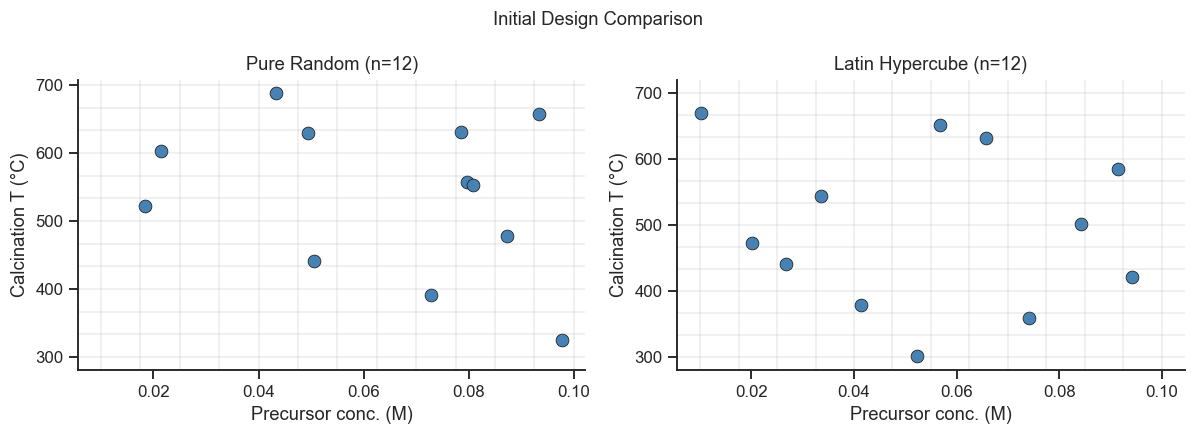

Min pairwise distance — Random: 1.9480
Min pairwise distance — LHS:    18.1920
(Higher = better space filling)


In [8]:
# ── Latin Hypercube Sampling (LHS) for initial design ────────────────────────
from scipy.stats import qmc

def lhs_design(n, bounds):
    """Generate n LHS points over the given bounds [(lo,hi),...]."""
    k = len(bounds)
    sampler = qmc.LatinHypercube(d=k, seed=42)
    unit_pts = sampler.random(n=n)            # [0,1]^k
    lo = np.array([b[0] for b in bounds])
    hi = np.array([b[1] for b in bounds])
    return qmc.scale(unit_pts, lo, hi)

# Compare LHS vs pure random for k=2, n=12
n_init_cmp = 12
bounds_cmp  = [(0.01, 0.10), (300., 700.)]

X_lhs  = lhs_design(n_init_cmp, bounds_cmp)
rng_r  = np.random.default_rng(42)
X_rand_cmp = np.column_stack([rng_r.uniform(b[0], b[1], n_init_cmp)
                               for b in bounds_cmp])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, X_des, title in zip(axes,
                              [X_rand_cmp, X_lhs],
                              ['Pure Random (n=12)', 'Latin Hypercube (n=12)']):
    ax.scatter(X_des[:, 0], X_des[:, 1], s=70, color='steelblue',
               edgecolors='k', linewidths=0.5)
    ax.set_xlabel('Precursor conc. (M)')
    ax.set_ylabel('Calcination T (°C)')
    ax.set_title(title)
    # Light grid showing the k×k bins
    for lo, hi, n in [(bounds_cmp[0][0], bounds_cmp[0][1], n_init_cmp),
                       (bounds_cmp[1][0], bounds_cmp[1][1], n_init_cmp)]:
        ticks = np.linspace(lo, hi, n_init_cmp + 1)
        if hi > 100:   # temperature axis
            for t in ticks: ax.axhline(t, color='grey', lw=0.3, alpha=0.5)
        else:
            for t in ticks: ax.axvline(t, color='grey', lw=0.3, alpha=0.5)
    sns.despine(ax=ax)

plt.suptitle('Initial Design Comparison', fontsize=12)
plt.tight_layout()
plt.show()

# Space-filling metric: minimum pairwise distance
from scipy.spatial.distance import pdist
print(f'Min pairwise distance — Random: {pdist(X_rand_cmp).min():.4f}')
print(f'Min pairwise distance — LHS:    {pdist(X_lhs).min():.4f}')
print('(Higher = better space filling)')


### Interpreting the Design Comparison

- **Pure random** can cluster points by chance — there may be large empty regions
  and some redundant near-duplicate experiments.
- **Latin Hypercube** guarantees that each row and each column in the grid has
  exactly one sample — far better coverage.  The minimum pairwise distance
  (printed above) is consistently larger for LHS.
- For a BO initial design, **LHS with $n_0 = 5k$** is the recommended default;
  for $k \leq 3$ a small full factorial (or central composite design) is also fine.

### Handling constraints

If the design space has a **forbidden region** (e.g., Al mol% + Li excess must
sum to ≤ 1.0), add a constraint penalty when maximising the acquisition function:

```python
def constrained_acq(x, gpr, y_best):
    if x[0] + x[2] > 1.0:        # constraint violated
        return 0.0
    return expected_improvement(x.reshape(1,-1), gpr, y_best).ravel()[0]
```

### Multi-response optimisation (Pareto front)

When you have two conflicting objectives — e.g., *maximise conductivity* and
*minimise sintering temperature* — a single acquisition function cannot directly
handle both.  Practical options:

| Strategy | When to use |
|---|---|
| **Weighted sum**: $y_{\text{agg}} = w_1 y_1 - w_2 y_2$ | Weights are known a priori |
| **Desirability function** (Chapter 14.5) | Non-linear scaling of each objective |
| **EHVI** (Expected Hypervolume Improvement) | Full Pareto-front exploration; use `BoTorch` |
| **Constraint BO**: maximise $y_1$ subject to $y_2 > \text{threshold}$ | One objective is really a constraint |


---
## Exercises

1. **Batch BO**: In lab practice you often run multiple experiments in parallel (a *batch*). Modify the BO loop to suggest a *batch* of 3 experiments per iteration using the *kriging believer* heuristic (fit the GP, predict the next point, add it as a "hallucinated" observation with predicted mean, repeat 3 times). Compare convergence with sequential BO.

2. **Noisy objective**: Increase `noise_std` to 0.10 in `black_box`. How does the convergence change? Why does BO handle noisy objectives more gracefully than steepest ascent?

3. **Multi-objective BO**: Suppose you also want to *minimise* particle size (a separate response). Set up a Pareto-front analysis using `scipy` or a manual grid prediction of both objectives. Identify the conditions that maximise rate while keeping particle size below a threshold.
